# PRUEBAS DE CLUSTERING APLICADO AL DATASET ELECTORAL LAPOP 2023

### INICIALIZACIÓN

In [14]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np

from src.clustering.traditional import KMedoids, HierarchicalClustering, DBSCAN
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

print("="*70)
print("TEST SIMPLE DE ALGORITMOS DE CLUSTERING")
print("="*70)

# Cargar dataset preprocesado
dataset_path = f"{PROCESSED_DATA_PATH}"
df = pd.read_csv(dataset_path)

print(f"\n✓ Dataset cargado:")
print(f"  Dimensiones: {df.shape[0]} registros × {df.shape[1]} variables")
print(f"  Missings: {df.isnull().sum().sum()}")
print(f"\nPrimeras 3 filas:")
print(df.head(3))
print("="*70)

TEST SIMPLE DE ALGORITMOS DE CLUSTERING

✓ Dataset cargado:
  Dimensiones: 1706 registros × 11 variables
  Missings: 0

Primeras 3 filas:
         q2  edre  q10inc  etid  ur  ocupoit  q1tc_r  q11n  q12cn  boletidnew  \
0  0.485714     6    1001     1   0        4       1     0  0.000           0   
1  0.528571     1    1005     1   0        6       0     1  0.250           1   
2  0.185714     3    1009     1   0        8       0     2  0.375           0   

   q3cn  
0     1  
1     0  
2     4  


### APLICACIÓN DE LOS ALGORITMOS

In [15]:
print("\n--- TEST K-MEDOIDS ---\n")

# Buscar k óptimo con método del codo + silhouette
print("Buscando k óptimo...")
k_range = range(2, 12)
resultados_k = []

for k in k_range:
    km_temp = KMedoids(n_clusters=k, random_state=42)
    km_temp.fit(df)
    metrics_temp = calculate_metrics(df, km_temp.labels_)
    resultados_k.append({
        'k': k,
        'inercia': km_temp.inertia_,
        'silhouette': metrics_temp['silhouette'],
        'davies_bouldin': metrics_temp['davies_bouldin']
    })
    print(f"  k={k}: Inercia={km_temp.inertia_:.2f} | "
          f"Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

# Buscar k óptimo: mayor silhouette
df_k = pd.DataFrame(resultados_k)
k_optimo_sil = df_k.loc[df_k['silhouette'].idxmax(), 'k']
k_optimo_db  = df_k.loc[df_k['davies_bouldin'].idxmin(), 'k']

print(f"\n  k óptimo por Silhouette:      k={k_optimo_sil}")
print(f"  k óptimo por Davies-Bouldin:  k={k_optimo_db}")

# Entrenar con k óptimo
k_final = int(k_optimo_sil)
print(f"\nEntrenando con k={k_final}...")
kmedoids = KMedoids(n_clusters=k_final, random_state=42)
kmedoids.fit(df)

# Distribución y métricas
print("\nDistribución:")
print(kmedoids.get_cluster_distribution())
print("\nMétricas:")
metrics_km = calculate_metrics(df, kmedoids.labels_)

print("="*70)


--- TEST K-MEDOIDS ---

Buscando k óptimo...
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 12188.7155
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.2034
  ✓ Davies-Bouldin Index: 1.9324
  ✓ Calinski-Harabasz Index: 283.1201
  k=2: Inercia=12188.72 | Sil=0.2034 | DB=1.9324
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 10893.8583
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.2441
  ✓ Davies-Bouldin Index: 1.4715
  ✓ Calinski-Harabasz Index: 547.3339
  k=3: Inercia=10893.86 | Sil=0.2441 | DB=1.4715
Entrenando K-Medoids con 4 clusters...
✓ K-Medoids entrenado: 4 clusters identificados
  Inercia: 10259.8405
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.1788
  ✓ Davies-Bouldin Index: 1.6582
  ✓ Calinski-Harabasz Index: 425.1081
  k=4: Inercia=10259.84 |

In [ ]:
print("\n--- TEST CLUSTERING JERÁRQUICO ---\n")

# PASO 1: Busqueda del mejor linkage (usando n_clusters provisional para comparar para linkages)
print("Paso 1: Comparando métodos de linkage...")
linkage_methods = ['ward', 'complete', 'average', 'single']
resultados_linkage = []

for linkage in linkage_methods:
    hc_temp = HierarchicalClustering(n_clusters=4, linkage=linkage)
    hc_temp.fit(df)
    metrics_temp = calculate_metrics(df, hc_temp.labels_)
    resultados_linkage.append({
        'linkage': linkage,
        'silhouette': metrics_temp['silhouette']
    })
    print(f"  {linkage:10s}: Sil={metrics_temp['silhouette']:.4f}")

mejor_linkage = max(resultados_linkage, key=lambda x: x['silhouette'])['linkage']
print(f"\n  Mejor linkage: '{mejor_linkage}'")

# PASO 2: Con el mejor linkage, buscar n_clusters óptimo
print(f"\nPaso 2: Buscando n_clusters óptimo con linkage='{mejor_linkage}'...")
resultados_n = []

for n in range(2, 12):
    hc_temp = HierarchicalClustering(n_clusters=n, linkage=mejor_linkage)
    hc_temp.fit(df)
    metrics_temp = calculate_metrics(df, hc_temp.labels_)
    resultados_n.append({
        'n_clusters': n,
        'silhouette': metrics_temp['silhouette'],
        'davies_bouldin': metrics_temp['davies_bouldin']
    })
    print(f"  n={n}: Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

df_n = pd.DataFrame(resultados_n)
n_optimo = int(df_n.loc[df_n['silhouette'].idxmax(), 'n_clusters'])
print(f"\n  n_clusters óptimo: {n_optimo}")

# PASO 3: Entrenar con los parámetros encontrados
print(f"\nPaso 3: Entrenando con n_clusters={n_optimo}, linkage='{mejor_linkage}'...")
hierarchical = HierarchicalClustering(n_clusters=n_optimo, linkage=mejor_linkage)
hierarchical.fit(df)

print("\nDistribución:")
print(hierarchical.get_cluster_distribution())
print("\nMétricas finales:")
metrics_hc = calculate_metrics(df, hierarchical.labels_)

print("="*70)


--- TEST CLUSTERING JERÁRQUICO ---

Paso 1: Comparando métodos de linkage...
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.1890
  ✓ Davies-Bouldin Index: 1.6673
  ✓ Calinski-Harabasz Index: 483.2296
  ward      : Sil=0.1890
Entrenando Clustering Jerárquico (complete)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.2647
  ✓ Davies-Bouldin Index: 1.6261
  ✓ Calinski-Harabasz Index: 291.3861
  complete  : Sil=0.2647
Entrenando Clustering Jerárquico (average)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.2648
  ✓ Davies-Bouldin Index: 1.1570
  ✓ Calinski-Harabasz Index: 218.6956
  average   : Sil=0.2648
Entrenando Clustering Jerárquico (single)...
✓ Clustering Jerárquico 


--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---

✓ Dendrograma guardado en: ../../figures/dendrograma_completo.png


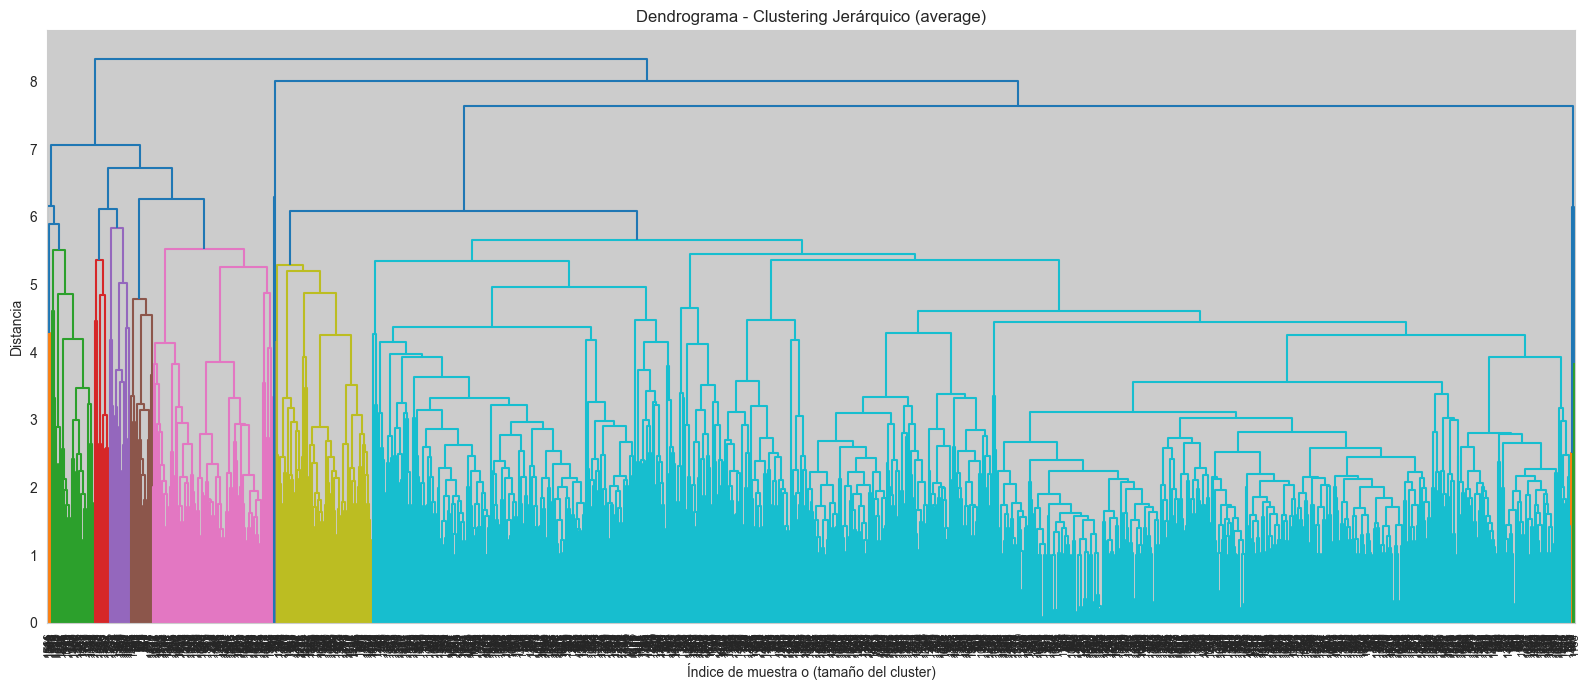

✓ Dendrograma guardado en: ../../figures/dendrograma_truncado.png


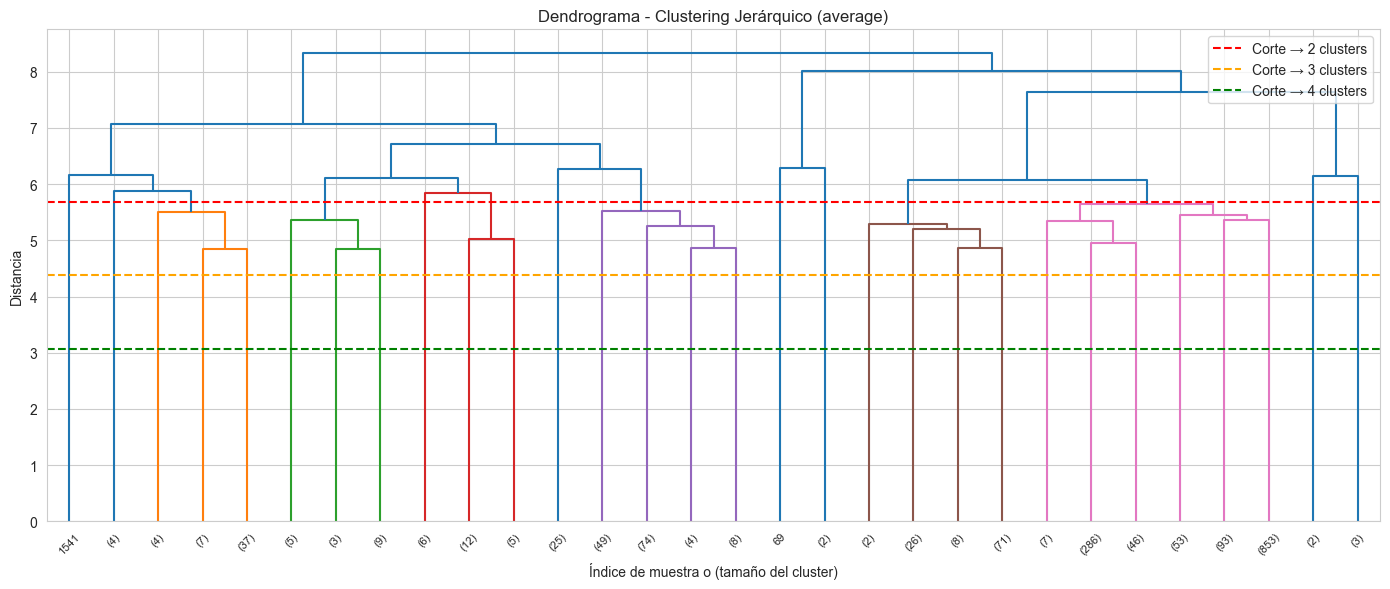


Interpretación:
  Linkage usado: average
  n_clusters actual: 2
  Silhouette: 0.3704

  Las líneas de corte muestran dónde cortar el dendrograma
  para obtener 2, 3 o 4 clusters.
  Los saltos grandes en altura = clusters naturales en los datos.


In [18]:
print("\n--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---\n")

fig1 = hierarchical.plot_dendrogram(
    figsize=(16, 7),
    truncate_mode=None,
    save_path='../../figures/dendrograma_completo.png'
)
plt.show()

fig2 = hierarchical.plot_dendrogram(
    figsize=(14, 6),
    truncate_mode='lastp',
    p=30,
    save_path='../../figures/dendrograma_truncado.png'
)

ax = plt.gca()
colores = ['red', 'orange', 'green']
alturas = [0.65, 0.50, 0.35] 

for altura, color, n in zip(alturas, colores, [2, 3, 4]):
    ax.axhline(
        y=altura * ax.get_ylim()[1],
        color=color,
        linestyle='--',
        linewidth=1.5,
        label=f'Corte → {n} clusters'
    )

ax.legend(loc='upper right')
plt.show()

print("\nInterpretación:")
print(f"  Linkage usado: {hierarchical.linkage}")
print(f"  n_clusters actual: {hierarchical.n_clusters_}")
print(f"  Silhouette: {metrics_hc['silhouette']:.4f}")
print("\n  Las líneas de corte muestran dónde cortar el dendrograma")
print("  para obtener 2, 3 o 4 clusters.")
print("  Los saltos grandes en altura = clusters naturales en los datos.")

In [17]:
print("\n--- TEST DBSCAN ---\n")

# DBSCAN con parámetros ajustados para datos de alta dimensionalidad
print("Probando diferentes configuraciones de DBSCAN...\n")

configs = [
    {'eps': eps, 'min_samples': ms}
    for eps in [1.0, 2.0, 3.0, 4.0, 5.0]
    for ms in [3, 5, 10]
]

mejor_config = None
mejor_sil = -1

for cfg in configs:
    db_temp = DBSCAN(**cfg)
    db_temp.fit(df)
    if db_temp.n_clusters_ >= 2:
        mask = db_temp.labels_ != -1
        sil = calculate_metrics(df[mask], db_temp.labels_[mask])['silhouette']
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: "
              f"{db_temp.n_clusters_} clusters, Sil={sil:.4f}")
        if sil > mejor_sil:
            mejor_sil = sil
            mejor_config = cfg
            dbscan = db_temp
    else:
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: sin clusters")

if mejor_config:
    print(f"\n✓ Mejor configuración: {mejor_config} → Sil={mejor_sil:.4f}")
else:
    print("⚠ Ninguna configuración generó clusters válidos")

print(f"\nConfiguración final: eps={dbscan.eps}, min_samples={dbscan.min_samples}")
print(f"Clusters identificados: {dbscan.n_clusters_}")
print(f"Puntos de ruido: {dbscan.n_noise_points_}")
print(f"\nTamaños:")
print(dbscan.get_cluster_sizes())

# Métricas (solo si hay suficientes clusters)
if dbscan.n_clusters_ >= 2:
    # Filtrar noise
    mask = dbscan.labels_ != -1
    df_clean = df[mask]
    labels_clean = dbscan.labels_[mask]
    
    print("\nMétricas (sin ruido):")
    metrics_db = calculate_metrics(df_clean, labels_clean)
else:
    print("\n⚠ DBSCAN no generó clusters válidos con ninguna configuración")
    print("  Esto puede ocurrir en datos de alta dimensionalidad")
    print("  DBSCAN requiere ajuste manual de parámetros según el dataset")
    metrics_db = None

print("="*70)


--- TEST DBSCAN ---

Probando diferentes configuraciones de DBSCAN...

Entrenando DBSCAN (eps=1.0, min_samples=3)...
✓ DBSCAN entrenado:
  Clusters identificados: 41
  Puntos de ruido: 1542 (90.39%)
  Puntos core: 150
Calculando métricas de validación...
  Muestras: 164
  Clusters: 41
  ✓ Silhouette Score: 0.5879
  ✓ Davies-Bouldin Index: 0.6005
  ✓ Calinski-Harabasz Index: 91.7473
  eps=1.0, min_samples=3: 41 clusters, Sil=0.5879
Entrenando DBSCAN (eps=1.0, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 5
  Puntos de ruido: 1669 (97.83%)
  Puntos core: 18
Calculando métricas de validación...
  Muestras: 37
  Clusters: 5
  ✓ Silhouette Score: 0.5783
  ✓ Davies-Bouldin Index: 0.6370
  ✓ Calinski-Harabasz Index: 48.6729
  eps=1.0, min_samples=5: 5 clusters, Sil=0.5783
Entrenando DBSCAN (eps=1.0, min_samples=10)...
✓ DBSCAN entrenado:
  Clusters identificados: 0
  Puntos de ruido: 1706 (100.00%)
  Puntos core: 0
  eps=1.0, min_samples=10: sin clusters
Entrenando DBSCAN (

### METRICAS Y RESUMEN

In [8]:
print("\n--- COMPARACIÓN DE ALGORITMOS ---\n")

# Tabla comparativa
comparison_data = {
    'Algoritmo': ['K-Medoids', 'Hierarchical', 'DBSCAN'],
    'Clusters': [kmedoids.n_clusters_, hierarchical.n_clusters_, dbscan.n_clusters_],
    'Silhouette': [
        metrics_km['silhouette'], 
        metrics_hc['silhouette'],
        metrics_db['silhouette'] if metrics_db else np.nan
    ],
    'Davies-Bouldin': [
        metrics_km['davies_bouldin'],
        metrics_hc['davies_bouldin'],
        metrics_db['davies_bouldin'] if metrics_db else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("✓ TEST COMPLETADO")
print("="*70)


--- COMPARACIÓN DE ALGORITMOS ---

   Algoritmo  Clusters  Silhouette  Davies-Bouldin
   K-Medoids        10    0.096115        2.082774
Hierarchical         4    0.189013        1.667262
      DBSCAN        41    0.587915        0.600469

✓ TEST COMPLETADO



--- VISUALIZACIÓN DE CLUSTERS ---

Aplicando PCA para reducir a 2 dimensiones...
✓ Varianza explicada: 59.34%
  PC1: 44.06%
  PC2: 15.28%


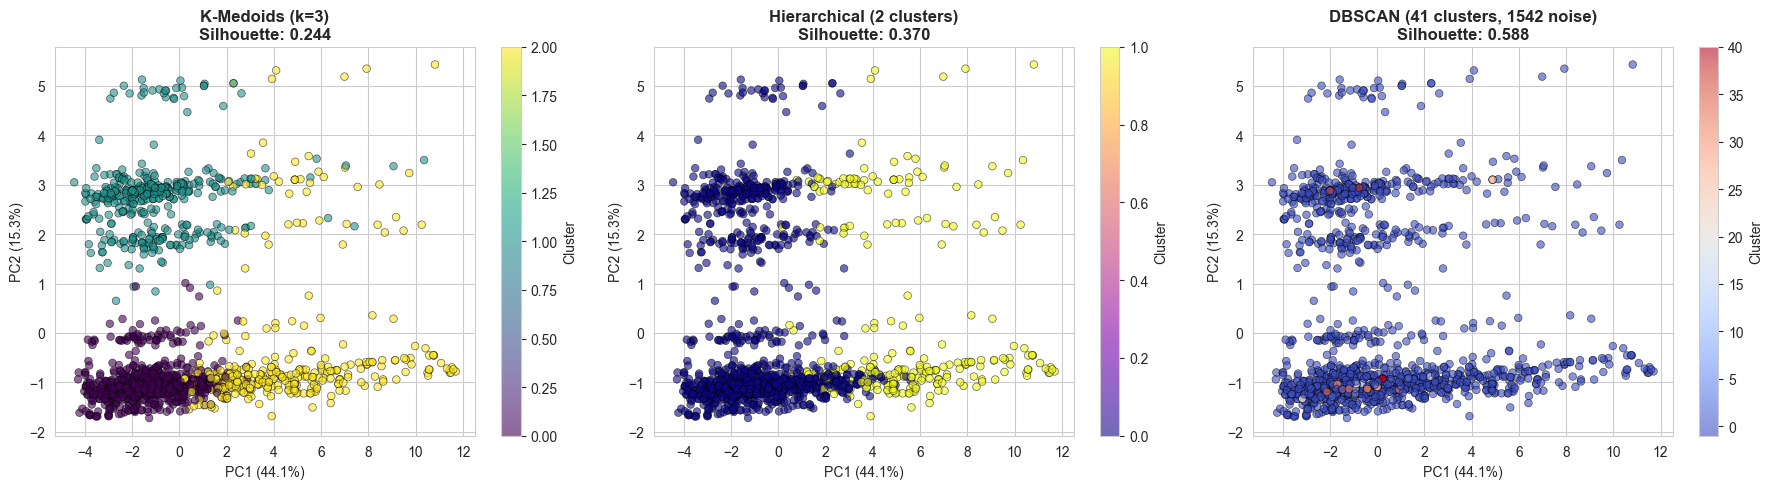


✓ Visualización guardada en: figures/comparacion_clusters_2d.png


In [13]:
print("\n--- VISUALIZACIÓN DE CLUSTERS ---\n")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)

# Reducir dimensionalidad a 2D con PCA
print("Aplicando PCA para reducir a 2 dimensiones...")
pca = PCA(n_components=2, random_state=42)
df_2d = pca.fit_transform(df)

print(f"✓ Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ====== K-Medoids ======
scatter1 = axes[0].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=kmedoids.labels_, 
    cmap='viridis', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_title(f'K-Medoids (k={kmedoids.n_clusters_})\nSilhouette: {metrics_km["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# ====== Hierarchical ======
scatter2 = axes[1].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=hierarchical.labels_, 
    cmap='plasma', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_title(f'Hierarchical ({hierarchical.n_clusters_} clusters)\nSilhouette: {metrics_hc["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# ====== DBSCAN ======
if dbscan.n_clusters_ >= 2:
    # DBSCAN con clusters válidos
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c=dbscan.labels_, 
        cmap='coolwarm', 
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN ({dbscan.n_clusters_} clusters, {dbscan.n_noise_points_} noise)\nSilhouette: {metrics_db["silhouette"]:.3f}'
else:
    # DBSCAN sin clusters (todo ruido)
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c='gray', 
        alpha=0.3,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN (Sin clusters)\nTodos los puntos = ruido'

axes[2].set_title(title, fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
if dbscan.n_clusters_ >= 2:
    plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.savefig('../../figures/comparacion_clusters_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada en: figures/comparacion_clusters_2d.png")
print("="*70)